In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import scale
import statsmodels.api as sm

In [74]:
df = pd.read_csv("/Users/nicholascullen/Documents/CA female births.csv")

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

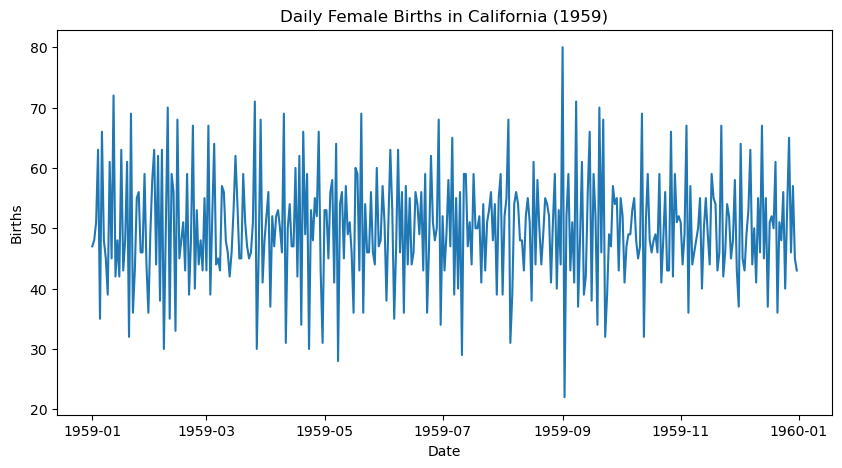

In [75]:
births = df['births']

plt.figure(figsize=(10,5))
plt.plot(births)
plt.title("Daily Female Births in California (1959)")
plt.xlabel("Date")
plt.ylabel("Births")
plt.show()

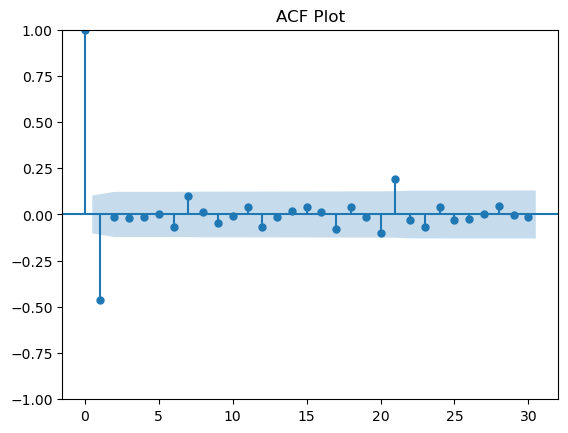

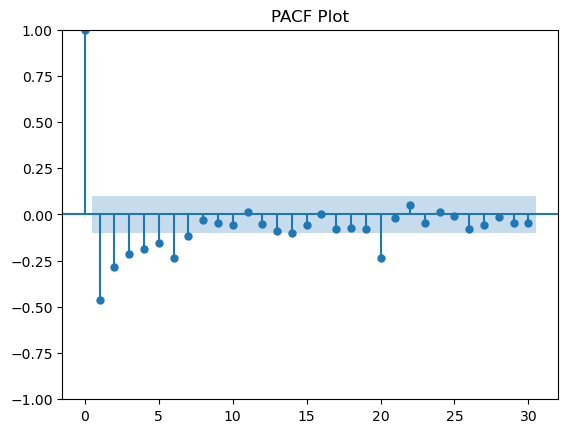

In [76]:
plot_acf(births, lags=30)
plt.title("ACF Plot")
plt.show()

plot_pacf(births, lags=30)
plt.title("PACF Plot")
plt.show()

In [77]:
model = ARIMA(births, order=(1,0,0))
fitted_model = model.fit()

print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 births   No. Observations:                  365
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1283.294
Date:                Fri, 17 Apr 2026   AIC                           2572.589
Time:                        20:19:27   BIC                           2584.288
Sample:                    01-01-1959   HQIC                          2577.238
                         - 12-31-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.0308      0.301    166.470      0.000      49.442      50.620
ar.L1         -0.4603      0.046     -9.924      0.000      -0.551      -0.369
sigma2        66.2375      4.989     13.277      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


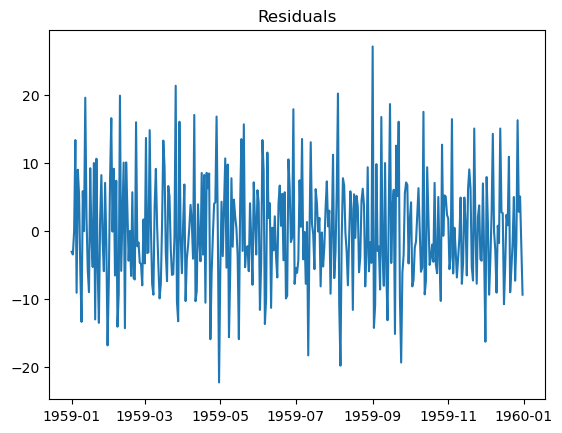

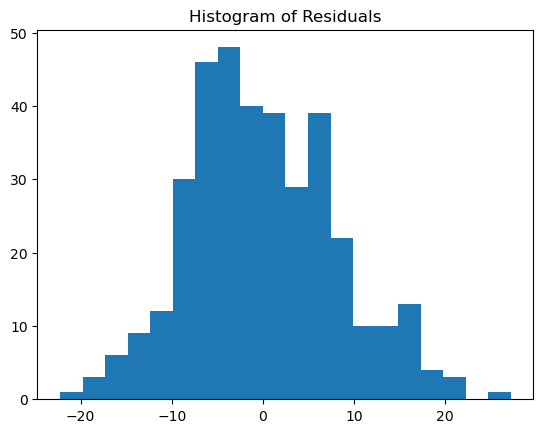

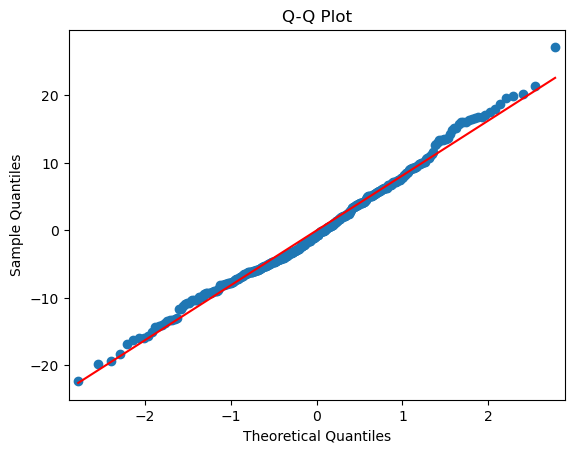

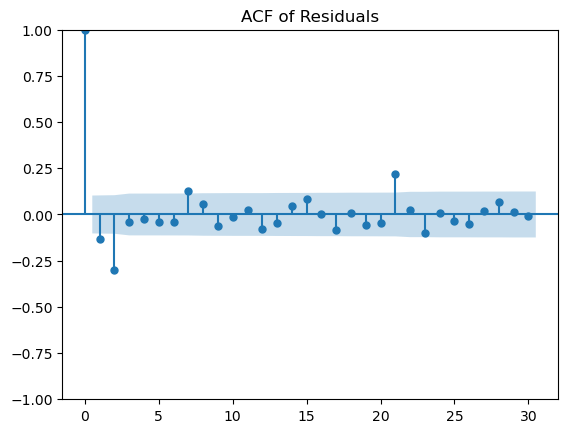

In [78]:
residuals = fitted_model.resid

plt.plot(residuals)
plt.title("Residuals")
plt.show()

plt.hist(residuals, bins=20)
plt.title("Histogram of Residuals")
plt.show()

sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot")
plt.show()

plot_acf(residuals, lags=30)
plt.title("ACF of Residuals")
plt.show()

In [79]:
model2 = ARIMA(births, order=(1,0,1))
fitted_model2 = model2.fit()

print(fitted_model2.summary())

                               SARIMAX Results                                
Dep. Variable:                 births   No. Observations:                  365
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1228.983
Date:                Fri, 17 Apr 2026   AIC                           2465.965
Time:                        20:19:27   BIC                           2481.565
Sample:                    01-01-1959   HQIC                          2472.165
                         - 12-31-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.0149      0.016   3175.367      0.000      49.984      50.046
ar.L1          0.1289      0.059      2.203      0.028       0.014       0.244
ma.L1         -0.9690      0.016    -61.943      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


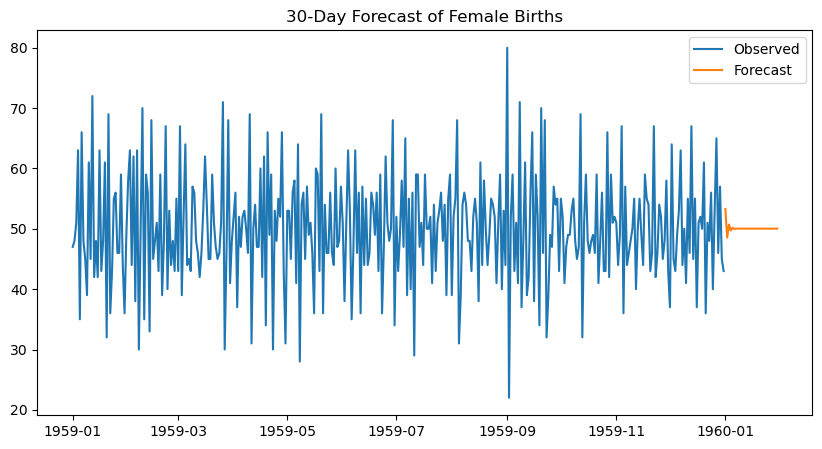

1960-01-01    53.267184
1960-01-02    48.540958
1960-01-03    50.716551
1960-01-04    49.715074
1960-01-05    50.176078
1960-01-06    49.963867
1960-01-07    50.061553
1960-01-08    50.016586
1960-01-09    50.037285
1960-01-10    50.027757
1960-01-11    50.032143
1960-01-12    50.030124
1960-01-13    50.031053
1960-01-14    50.030625
1960-01-15    50.030822
1960-01-16    50.030732
1960-01-17    50.030773
1960-01-18    50.030754
1960-01-19    50.030763
1960-01-20    50.030759
1960-01-21    50.030761
1960-01-22    50.030760
1960-01-23    50.030760
1960-01-24    50.030760
1960-01-25    50.030760
1960-01-26    50.030760
1960-01-27    50.030760
1960-01-28    50.030760
1960-01-29    50.030760
1960-01-30    50.030760
Freq: D, Name: predicted_mean, dtype: float64


In [80]:
forecast = fitted_model.forecast(steps=30)

# Create proper future dates
last_date = births.index[-1]
forecast_index = pd.date_range(start=last_date, periods=31, freq='D')[1:]

plt.figure(figsize=(10,5))
plt.plot(births, label="Observed")
plt.plot(forecast_index, forecast, label="Forecast")

plt.legend()
plt.title("30-Day Forecast of Female Births")
plt.show()

print(forecast)